In [90]:
import json

import gc_utils
import gizmo_analysis as gizmo
import matplotlib.pyplot as plt
import numpy as np
import numpy.ma as ma
from matplotlib import colors

In [91]:
sim = "m12m"
# sim_dir = "/Users/z5114326/Documents/simulations/"
sim_dir = "/Volumes/Expansion/simulations/"

sim_codes = sim_dir + "simulation_codes.json"
with open(sim_codes) as sim_json:
    sim_data = json.load(sim_json)

In [92]:
fire_dir = sim_dir + sim + "/" + sim + "_res7100/"
# halt = gc_utils.get_halo_tree(sim, sim_dir, species="star")
part = gc_utils.open_snapshot(600, fire_dir, species=["star"])

Retrieving Snapshot 600..................: 100%|████████████████████████████████████████████████████████████████████████| 1/1 [00:21<00:00, 21.72s/it]


In [93]:
r_lim = 25
distance_bin_width = 0.1
position_bin_number = int(np.round(2 * np.max(r_lim) / distance_bin_width))

pos_cyl = part["star"].prop("host.distance.principal.cylindrical")
r_msk = pos_cyl[:, 0] <= r_lim
z_msk = np.abs(pos_cyl[:, 2]) <= 1
pos = part["star"].prop("host.distance.principal")[r_msk & z_msk]
age = part["star"].prop("age")[r_msk & z_msk]

In [94]:
r_lim = 10

x = pos[:, 0]
y = pos[:, 1]

x_bins = np.arange(-r_lim, r_lim + distance_bin_width, distance_bin_width)
y_bins = np.arange(-r_lim, r_lim + distance_bin_width, distance_bin_width)

# Compute 2D histogram of counts and sum of ages
counts, _, _ = np.histogram2d(x, y, bins=[x_bins, y_bins])
age_sum, _, _ = np.histogram2d(x, y, bins=[x_bins, y_bins], weights=age)

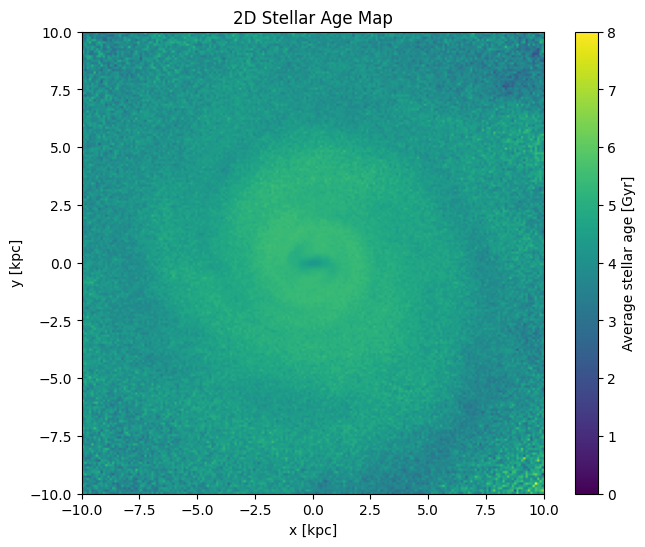

In [95]:
# Avoid division by zero
with np.errstate(divide="ignore", invalid="ignore"):
    age_avg = np.where(counts > 0, age_sum / counts, np.nan)

# Plot the 2D average age map
plt.figure(figsize=(8, 6))
plt.imshow(
    age_avg.T,  # transpose so x/y axes match
    origin="lower",
    extent=[x_bins[0], x_bins[-1], y_bins[0], y_bins[-1]],
    aspect="equal",
    cmap="viridis",
    vmin=0,
    vmax=8,
)
plt.colorbar(label="Average stellar age [Gyr]")
plt.xlabel("x [kpc]")
plt.ylabel("y [kpc]")
plt.title("2D Stellar Age Map")
plt.show()